In [1]:
import matplotlib.pyplot as plt
import random
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
import numpy as np

#for WM811K
import cv2
import pandas as pd

In [3]:
#Data for 811K
wm811K = pd.read_pickle('data/wm811K.pkl')

wm811K.info()

<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dieSize         811457 non-null  float64
 1   failureType     811457 non-null  object 
 2   lotName         811457 non-null  object 
 3   trainTestLabel  811457 non-null  object 
 4   waferIndex      811457 non-null  float64
 5   waferMap        811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [3]:
#Data for MixedWM38

data = np.load('data/MixedWM38.npz')
print(data.files)

['arr_0', 'arr_1']


WM811K attempt

In [4]:
wm811K.head()

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
0,1683.0,none,lot1,Training,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1683.0,none,lot1,Training,2.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1683.0,none,lot1,Training,3.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1683.0,none,lot1,Training,4.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1683.0,none,lot1,Training,5.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [5]:
#need to fix some of the dataset labels
wm811K.rename(columns={'trianTestlabel': 'trainTestLabel'}, inplace=True)
wm811K.waferIndex = wm811K.waferIndex.astype(int)
wm811K.tail()

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
811452,600.0,Edge-Ring,lot47542,Test,23,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811453,600.0,Edge-Loc,lot47542,Test,24,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,..."
811454,600.0,Edge-Ring,lot47542,Test,25,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811455,600.0,"[0, 0]",lot47543,"[0, 0]",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,..."
811456,600.0,"[0, 0]",lot47543,"[0, 0]",2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."


In [6]:
#Dont need index
wm811K.drop(['waferIndex'], axis = 1)

,dieSize,failureType,lotName,trainTestLabel,waferMap
0,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...
811452,600.0,Edge-Ring,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811453,600.0,Edge-Loc,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,..."
811454,600.0,Edge-Ring,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811455,600.0,"[0, 0]",lot47543,"[0, 0]","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,..."


In [7]:
#Find wafer map dimensions
def find_dimension(x):
    dimension0 = np.size(x, 0)
    dimension1 = np.size(x, 1)
    return dimension0, dimension1
wm811K['waferMapDim'] = wm811K.waferMap.apply(find_dimension)
wm811K.sample(5)

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap,waferMapDim
419222,1724.0,"[0, 0]",lot25148,"[0, 0]",19,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(50, 43)"
472952,1513.0,"[0, 0]",lot29125,"[0, 0]",16,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(49, 39)"
380754,2393.0,"[0, 0]",lot22719,"[0, 0]",9,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(52, 59)"
679806,845.0,none,lot42202,Test,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...","(35, 31)"
695731,3104.0,none,lot42852,Test,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(62, 64)"


In [8]:
wm811K.memory_usage(deep=True)

Index                   132
dieSize             6491656
failureType        85867952
lotName            46088917
trainTestLabel     86004610
waferIndex          6491656
waferMap          110358152
waferMapDim        51933248
dtype: int64

In [10]:
#make a copy to take up less memory

wm811K2 = wm811K.copy()
wm811K2.failureType = wm811K2.failureType.apply(lambda x: x[0][0] if len(x) > 0 else float("NaN"))
wm811K2.trainTestLabel = wm811K2.trainTestLabel.apply(lambda x: x[0][0] if len(x) > 0 else float("NaN"))
wm811K2.sample()

IndexError: invalid index to scalar variable.

END OF WM811K Attempt

In [4]:
#Mixed Set

for key in data.files:
  print(key, data[key].shape)
  # 38,015 wafer maps, 52x52
  #arr_1 38,015 label vectors with length 8 for each defect present

arr_0 (38015, 52, 52)
arr_1 (38015, 8)


In [5]:
images = data['arr_0']
labels = data['arr_1']

#Adding 9th defect directly
no_defect = (labels.sum(axis = 1, keepdims = True) == 0).astype(np.float32)
labels = np.concatenate((labels, no_defect), axis = 1)

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: (38015, 52, 52)
Label shape: (38015, 9)


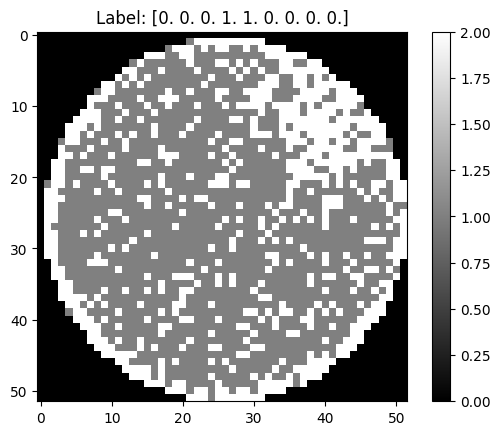

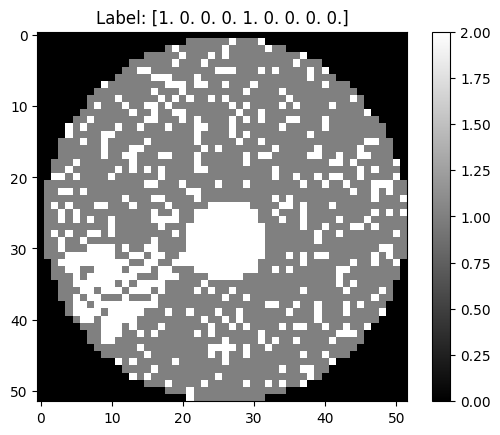

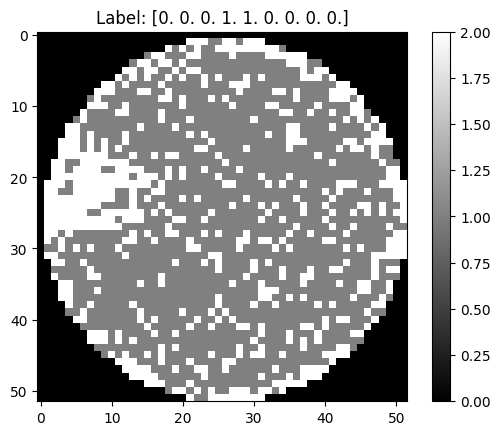

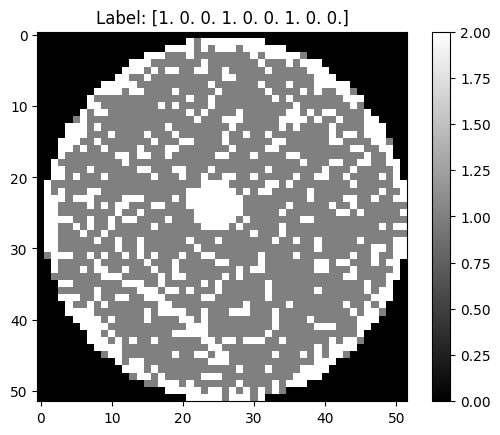

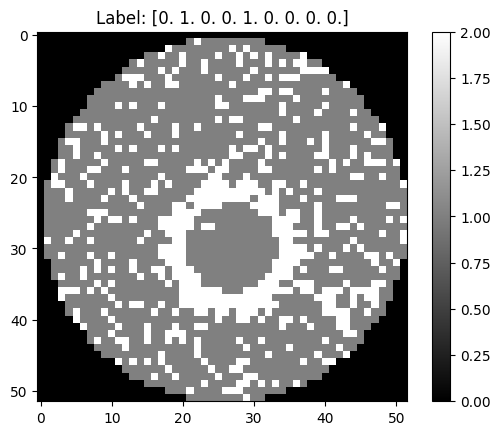

In [6]:
for i in random.sample(range(len(images)), 5):
  plt.imshow(images[i], cmap = 'gray')
  plt.title(f"Label: {labels[i]}")
  plt.colorbar()
  plt.show()

In [7]:
#Need to normalize the scale from 0-2 to 0-1
images = images.astype('float32')
images = images / 2.0

In [8]:
#Need to convert shape for pytorch
images = np.expand_dims(images, axis = 1)
print(images.shape)

(38015, 1, 52, 52)


In [9]:
#Count the defect dies per defect
def DefectCounter(image):
  return (image == 1.0).sum()
#1.0 == defect, 0.5 == good due to pre process

In [10]:
#make the values for both image shape and label shape into torch tensors
image_tensor = torch.tensor(images)
label_tensor = torch.tensor(labels).float()

print(image_tensor.shape)
print(label_tensor.shape)

torch.Size([38015, 1, 52, 52])
torch.Size([38015, 9])


In [11]:
#Test counting total dies per wafer class
defect_array = np.zeros(9)
#Fix Label tensor in order to get some count for 9th class

for i in range(len(images)):
  imageNum = images[i]
  labelNum = labels[i]

  current_Count = DefectCounter(imageNum)

  for j in range(len(labelNum)):
    if labelNum[j] == 1.0:
      defect_array[j] += current_Count
print(f'Number of defects per class: {defect_array}')


Number of defects per class: [ 8423293.  9025641.  8425165.  9003538. 12508552.   265663. 12750854.
   863236.   161571.]


In [12]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(image_tensor, label_tensor, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

torch.Size([30412, 1, 52, 52])
torch.Size([7603, 1, 52, 52])


In [12]:
#Created dataloaders to process in batches

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64)

In [13]:
#checked number of each defect type
print(label_tensor.sum(dim = 0))

tensor([13000., 12000., 13000., 12000., 18000.,   149., 19000.,   866.,  1000.])


In [14]:
#send to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
#Starting the simple CNN
class SimpleCNN(nn.Module):
  #Autofilled by copiolt
  def __init__(self):
    super(SimpleCNN, self).__init__()

    #First layer: Input wafer 1, output 32, with kernel 3x3
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding =1)
    #adding batch normalization
    self.bn1 = nn.BatchNorm2d(32)

    #Second layer: take 32, output 64, same kernel
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
    self.bn2 = nn.BatchNorm2d(64)

    #3rd layer
    self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
    self.bn3 = nn.BatchNorm2d(128)

    #4th layer
    self.conv4 = nn.Conv2d(in_channels = 128, out_channels =128, kernel_size = 3, padding = 1)
    self.bn4 = nn.BatchNorm2d(128)

    #5th layer
    self.conv5 = nn.Conv2d(in_channels = 128, out_channels = 256, kernel_size = 3, padding =1)
    self.bn5 = nn.BatchNorm2d(256)

    #reduce the size by half
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

    #added dropout for overfitting
    self.dropout = nn.Dropout(0.25)

    #connect layers; 13x13 because 52 -> 26 -> 13
    self.fc1 = nn.Linear(in_features = 256 * 1 * 1, out_features = 128)
    self.fc2Classify = nn.Linear(in_features = 128, out_features = 9) #Goes to 8 different defects
    #self.fc3Regression = nn.Linear(in_features = 128, out_features = 8) #Regression

  def forward(self, x):
    #52 - 26
    x = self.pool(F.relu(self.bn1((self.conv1(x)))))
    #26 - 13
    x = self.pool(F.relu(self.bn2((self.conv2(x)))))
    #
    x = self.pool(F.relu(self.bn3((self.conv3(x)))))
    #Recommended dropout to deal with overfitting
    x = self.dropout(x)
    #
    x = self.pool(F.relu(self.bn4((self.conv4(x)))))
    #
    x = self.pool(F.relu(self.bn5((self.conv5(x)))))
    x = self.dropout(x)

    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    #apply dropout
    x = self.dropout(x)
    ClassificationResult = self.fc2Classify(x)
    #RegressionResult = self.fc3Regression(x)

    return ClassificationResult

In [16]:

model = SimpleCNN().to(device)
#Loss function/ Added new loss for regression
criterion_class = nn.BCEWithLogitsLoss()
#criterion_regress = nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) #Changing around learning rate

In [17]:
#New training loop
epoch_num = 10

for epoch in range(epoch_num):
  model.train()
  current_loss = 0.0

  for image, labels in train_loader:
    image = image.to(device)
    labels = labels.to(device)
    #counts = counts.to(device)

    #Pass forward
    Classification_out = model(image)

    #get loss/ New losses needed to be added
    loss = criterion_class(Classification_out, labels)
    #loss2 = criterion_regress(Regression_out, counts)

    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    current_loss += loss.item()

  print(f"Epoch [{epoch+1}/{epoch_num}], Loss: {current_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.1229
Epoch [2/10], Loss: 0.0352
Epoch [3/10], Loss: 0.0258
Epoch [4/10], Loss: 0.0200
Epoch [5/10], Loss: 0.0181
Epoch [6/10], Loss: 0.0153
Epoch [7/10], Loss: 0.0131
Epoch [8/10], Loss: 0.0124
Epoch [9/10], Loss: 0.0102
Epoch [10/10], Loss: 0.0095


In [18]:
print(train_loader.batch_size)

64


In [19]:
#Multilabel accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for image, labels in test_loader:
    image = image.to(device)
    labels = labels.to(device)
    #Including counts for regression
    #counts = counts.to(device)

    class_out = model(image)
    predicted = torch.sigmoid(class_out) > 0.5

    #Changed prediction labels to match only to 1's
    correct += (predicted == labels).all(dim = 1).sum().item()
    #.Numel = number of elements from torch
    total += labels.size(0)

    #Checking regression results
    #for i in range(20):
      #print(f"Predicted counts by regression: {reg_out[i]}")
      #print(f"Actual counts: {counts[i]}")

print("Accuracy:", correct / total)

Accuracy: 0.9656714454820465


In [20]:
#accuracy was very high for the simple model, trying some other stuff
#Finding count of every label in the sample
all_labels = []
for _, labels in test_loader:
  all_labels.append(labels)

all_labels = torch.cat(all_labels)

print(f"Counting of each defect class: {all_labels.sum(dim = 0)}")

Counting of each defect class: tensor([2587., 2377., 2605., 2404., 3604.,   34., 3713.,  179.,  220.])


In [21]:
#Using F1 like other papers
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    predictions = torch.sigmoid(outputs) > 0.5

    all_predictions.append(predictions.cpu())
    all_targets.append(labels)

all_predictions = torch.cat(all_predictions).numpy()
all_targets = torch.cat(all_targets).numpy()

print("Macro F1:", f1_score(all_targets, all_predictions, average = 'macro'))
print("Micro F1:", f1_score(all_targets, all_predictions, average = 'micro'))

Macro F1: 0.9869515717169178
Micro F1: 0.9912803002511499


In [22]:
print(classification_report(all_targets, all_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2587
           1       1.00      1.00      1.00      2377
           2       1.00      0.97      0.99      2605
           3       0.98      1.00      0.99      2404
           4       1.00      0.98      0.99      3604
           5       0.97      0.91      0.94        34
           6       0.97      1.00      0.99      3713
           7       0.98      1.00      0.99       179
           8       1.00      1.00      1.00       220

   micro avg       0.99      0.99      0.99     17723
   macro avg       0.99      0.98      0.99     17723
weighted avg       0.99      0.99      0.99     17723
 samples avg       0.99      0.99      0.99     17723



c:\Users\raros\OneDrive\Desktop\VS code\WaferProject\defect_detect_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
#Check class distribution
print(y_train.sum(dim = 0 ))
print(y_test.sum( dim = 0))

tensor([10413.,  9623., 10395.,  9596., 14396.,   115., 15287.,   687.,   780.])
tensor([2587., 2377., 2605., 2404., 3604.,   34., 3713.,  179.,  220.])


Starting GAN Implementation

In [13]:
class_count = labels.sum(axis = 0)

for i, count in enumerate(class_count):
  print(f"Defect class {i + 1}: {int(count)} samples")

Defect class 1: 13000 samples
Defect class 2: 12000 samples
Defect class 3: 13000 samples
Defect class 4: 12000 samples
Defect class 5: 18000 samples
Defect class 6: 149 samples
Defect class 7: 19000 samples
Defect class 8: 866 samples
Defect class 9: 1000 samples
